# CNASim Performance

The experiment evaluates tree reconstruction performance on CNAsim data. This notebook shows the workflow steps.

In [48]:
# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import os

import scgenome.plotting as pl
import anndata
from Bio import Phylo
from io import StringIO

from cellmates.utils.tree_utils import write_newick, nxtree_to_newick, newick_to_nx, make_gt_tree_dist


In [3]:
# data is generated from CNAsim

In [4]:
# converted to anndata

In [50]:
data_path = "../../results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2"

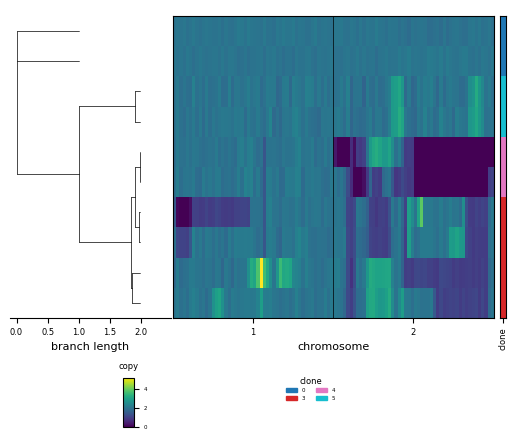

In [51]:
# plot example
adata = anndata.read_h5ad(os.path.join(data_path, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=['clone'], raw=True)

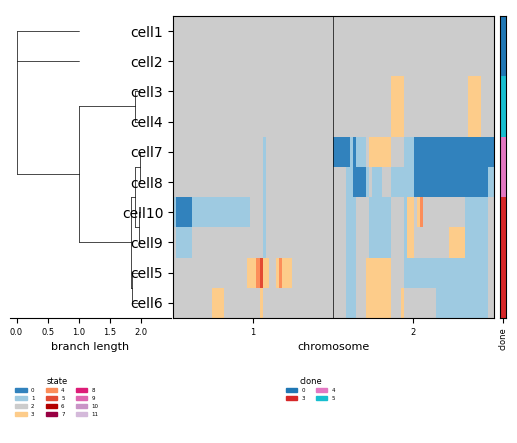

In [52]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree, annotation_fields=['clone'], show_cell_ids=True)

# GT copy number distances

['cell3', 'cell4', 'cell5', 'cell6', 'cell7', 'cell8', 'cell9', 'cell10']


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


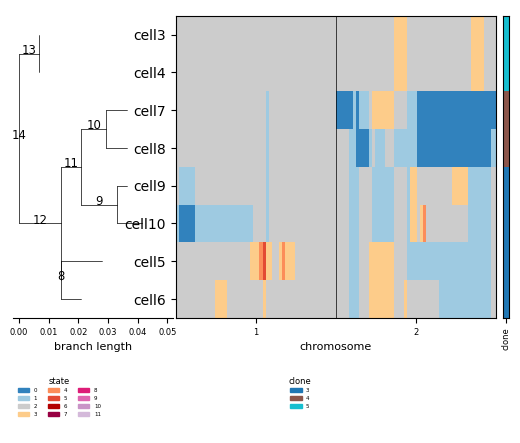

In [53]:
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
print(cell_names)
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)

In [36]:
gt_tree_nwk = adata.uns['cell-tree-newick']
print(gt_tree_nwk)

(cell1:1.0,cell2:1.0,((cell3:0.09434725027552811,cell4:0.09434725027552811)ancestor1:1.4180459476327667,(((cell7:0.03457921967643286,cell8:0.03457921967643286)ancestor5:0.11882096929061069,cell5:0.15340018896704355)ancestor3:0.20540931415671287,((cell10:0.09943032310816553,cell9:0.09943032310816553)ancestor6:0.11960985748661344,cell6:0.21904018059477898)ancestor4:0.13976932252897745)ancestor2:1.1535836947845384)founder:1.0)root;


In [37]:
print(bio_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=1.0, name='cell1')
        Clade(branch_length=1.0, name='cell2')
        Clade(branch_length=1.0, name='founder')
            Clade(branch_length=1.4180459476327667, name='ancestor1')
                Clade(branch_length=0.09434725027552811, name='cell3')
                Clade(branch_length=0.09434725027552811, name='cell4')
            Clade(branch_length=1.1535836947845384, name='ancestor2')
                Clade(branch_length=0.20540931415671287, name='ancestor3')
                    Clade(branch_length=0.11882096929061069, name='ancestor5')
                        Clade(branch_length=0.03457921967643286, name='cell7')
                        Clade(branch_length=0.03457921967643286, name='cell8')
                    Clade(branch_length=0.15340018896704355, name='cell5')
                Clade(branch_length=0.13976932252897745, name='ancestor4')
                    Clade(branch_length=0.11960985748661344

In [38]:
em_nwk = open(os.path.join(data_path, "cm_out", "tree.nwk")).read()
print(em_nwk)

((((cell8:0.0038600167961931773,cell9:0.006608747074464394)ancestor5:0.0030542164706339626,cell5:0.013086968286886899)ancestor3:0.004741266066305025,((cell4:0.021623674336653437,cell7:0.0042825246255721984)ancestor6:0.00018648664259183004,cell6:0.010040245054708574)ancestor4:0.00967961046189093)ancestor1:0.0014248202317200314,(cell10:0.01054605440649931,cell3:0.006750245097840169)ancestor2:0.0014248202317200314)root;


In [39]:
inferred_tree = Phylo.read(os.path.join(data_path, "cm_out", "tree.nwk"), 'newick')

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


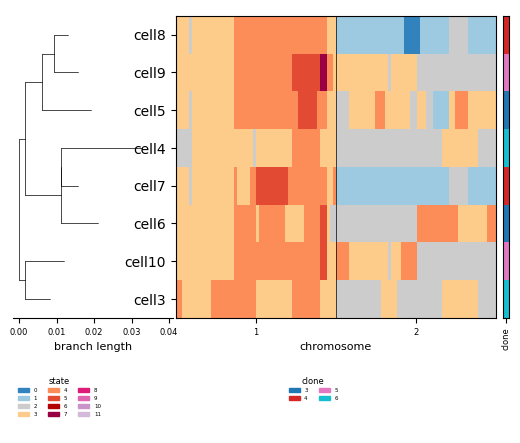

In [41]:
# output tree
# print(inferred_tree)
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)


In [12]:
print(inferred_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=6.829978051389932e-15, name='ancestor1')
            Clade(branch_length=6.829978051389932e-15, name='ancestor2')
                Clade(branch_length=1.3659956102779864e-14, name='ancestor3')
                    Clade(branch_length=2.7319912205559728e-14, name='ancestor4')
                        Clade(branch_length=5.4639824411119456e-14, name='ancestor5')
                            Clade(branch_length=1.0927964882223891e-13, name='ancestor6')
                                Clade(branch_length=8.95235076603404e-12, name='ancestor7')
                                    Clade(branch_length=0.001779955779563772, name='ancestor8')
                                        Clade(branch_length=0.005105647151597669, name='cell8')
                                        Clade(branch_length=0.003521362748037286, name='cell9')
                                    Clade(branch_length=0.0034073165531906587, name='cel

In [47]:
adata.uns['cnasim-params']


{'Time': 2,
 'WGD': False,
 'bin_length': 1000000,
 'chrom_arm_rate': 0.75,
 'chrom_arm_ratio': 0.5,
 'chrom_event_type': 0.5,
 'chrom_length': 50000000,
 'chrom_level_event': False,
 'chrom_rate_clone': 1,
 'chrom_rate_founder': 2,
 'chrom_rate_super_clone': 1,
 'clone_criteria': 0,
 'cn_copy_param': 0.8,
 'cn_event_rate': 0.5,
 'cn_length_mean': 10000000,
 'coverage': 0.2,
 'disable_info': False,
 'error_rate_1': 0.04,
 'error_rate_2': 0.1,
 'founder_event_mult': 10,
 'growth_rate': 0.003785,
 'interval': 3,
 'lorenz_x': 0.5,
 'lorenz_y': 0.4,
 'min_cn_length': 1000,
 'mode': 1,
 'normal_fraction': 0.2,
 'num_cells': 10,
 'num_chromosomes': 2,
 'num_clones': 2,
 'num_sweep': 0,
 'out_path': ' results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2/cnasim_tmp',
 'placement_param': 2,
 'placement_type': 0,
 'processors': 1,
 'pseudonormal_fraction': 0,
 'read_length': 150,
 'region_length': 1000,
 'selection_strength': 0.01,
 'seq_error': 0.02,
 'tree_type': 0,
 'use_hg38_static': False,
 'use_